# 1) NumPy

In [1]:
import numpy as np
import pandas as pd

In [2]:
matrix = np.random.randint(1,100, size=(5,5))
matrix

array([[85, 83, 37, 18, 33],
       [88, 45, 95, 69, 15],
       [26,  5, 84, 44, 50],
       [40, 13, 31, 74, 90],
       [32, 82, 60, 94, 86]])

### a)

In [3]:
print(matrix[2, 2])

84


### b)

In [4]:
for i in range(len(matrix)):
    print(np.mean(matrix[i, 0:]))

51.2
62.4
41.8
49.6
70.8


### c)

In [5]:
newArr = matrix[matrix > np.mean(matrix)]
newArr

array([85, 83, 88, 95, 69, 84, 74, 90, 82, 60, 94, 86])

### d)

In [6]:
def numpy_spiral_order(matrix):
    result = []
    if matrix.size == 0:
        return result

    top, left = 0, 0
    bottom = matrix.shape[0] - 1
    right = matrix.shape[1] - 1

    while top <= bottom and left <= right:
        result.extend(matrix[top, left:right + 1].tolist())
        top += 1

        if top <= bottom:
            result.extend(matrix[top:bottom + 1, right].tolist())
            right -= 1

        if left <= right and top <= bottom:
            result.extend(matrix[bottom, left:right + 1][::-1].tolist())
            bottom -= 1

        if top <= bottom and left <= right:
            result.extend(matrix[top:bottom + 1, left][::-1].tolist())
            left += 1

    return result

print("Spiral Order:", numpy_spiral_order(matrix))

Spiral Order: [85, 83, 37, 18, 33, 15, 50, 90, 86, 94, 60, 82, 32, 40, 26, 88, 45, 95, 69, 44, 74, 31, 13, 5, 84]


# Video Game Sales

### a)

In [7]:
data = pd.read_csv('videogamesales.csv')
data['global_sales'] = data.iloc[:, 5:9].sum(axis=1)
data.sort_values('global_sales')

data

,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,global_sales
0,Asteroids,2600,1980.0,Shooter,Atari,4.00,0.26,0.00,0.05,4.31
1,Missile Command,2600,1980.0,Shooter,Atari,2.56,0.17,0.00,0.03,2.76
2,Kaboom!,2600,1980.0,Misc,Activision,1.07,0.07,0.00,0.01,1.15
3,Defender,2600,1980.0,Misc,Atari,0.99,0.05,0.00,0.01,1.05
4,Boxing,2600,1980.0,Fighting,Activision,0.72,0.04,0.00,0.01,0.77
...,...,...,...,...,...,...,...,...,...,...
16578,WRC: FIA World Rally Championship,X360,NaN,Racing,Black Bean Games,0.00,0.10,0.00,0.02,0.12
16579,WRC: FIA World Rally Championship,PC,NaN,Racing,Black Bean Games,0.00,0.01,0.00,0.00,0.01
16580,Writing and Speaking Beautiful Japanese DS,DS,NaN,Misc,Unknown,0.00,0.00,0.02,0.00,0.02
16581,Yu-Gi-Oh! 5D's Wheelie Breakers (JP sales),Wii,NaN,Racing,Unknown,0.00,0.00,0.02,0.00,0.02


### b)

In [8]:
import matplotlib.pyplot as plt

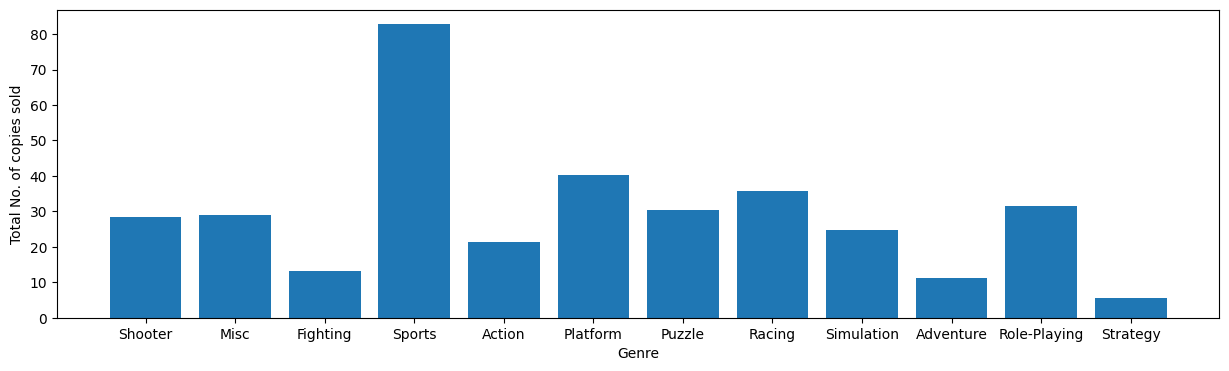

In [9]:
plt.figure(figsize=(15,4))

plt.bar(data['Genre'], data['global_sales'])
plt.xlabel('Genre')
plt.ylabel('Total No. of copies sold')

plt.show()

### c)

In [10]:
new_df = data.loc[data['Name'].str.contains('Grand Theft Auto')]
new_df.reset_index(drop=True, inplace=True)
new_df['sum'] = new_df.iloc[:, 6:8].sum(axis=1)


new_df.loc[:, ['Name', 'Platform', 'Year', 'sum']]

/var/folders/w1/gbwfkd5560xgjzz_fjrxwzvc0000gn/T/ipykernel_6361/3832370794.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['sum'] = new_df.iloc[:, 6:8].sum(axis=1)


,Name,Platform,Year,sum
0,Grand Theft Auto,PS,1997.0,1.39
1,Grand Theft Auto 2,PS,1998.0,2.07
2,"Grand Theft Auto: Mission Pack #1, London 1969",PS,1998.0,0.04
3,Grand Theft Auto III,PS2,2001.0,4.81
4,Grand Theft Auto: Vice City,PS2,2002.0,5.96
5,Grand Theft Auto III,PC,2002.0,0.01
6,Rockstar Games Double Pack: Grand Theft Auto I...,XB,2003.0,0.56
7,Rockstar Games Double Pack: Grand Theft Auto I...,PS2,2003.0,0.66
8,Grand Theft Auto: Vice City,PC,2003.0,0.03
9,Grand Theft Auto: San Andreas,PS2,2004.0,0.81


### d)

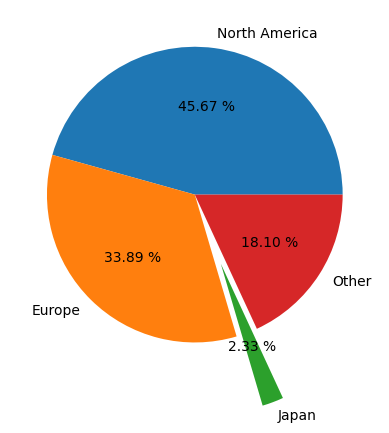

In [11]:
NA = new_df.iloc[:, 5].sum(axis=0)
EU = new_df.iloc[:, 6].sum(axis=0)
JP = new_df.iloc[:, 7].sum(axis=0)
other = new_df.iloc[:, 8].sum(axis=0)

region = [NA, EU, JP, other]
labels = ['North America', 'Europe', 'Japan', 'Other']

plt.pie(region, labels=labels, explode=(0,0, 0.5, 0) ,autopct='%.2f %%')

plt.show()